In [1]:
import torch

In [2]:
# check cuda
torch.cuda.is_available()

False

In [3]:
# check mac supports pytorch acceleration
torch.backends.mps.is_available()

True

In [4]:
tensor0d = torch.tensor(1)                #1

print(tensor0d.shape)

tensor1d = torch.tensor([1, 2, 3])        #2

print(tensor1d.shape)

tensor2d = torch.tensor([[1, 2],
                         [3, 4]])         #3

print(tensor2d.shape)

tensor3d = torch.tensor([[[1, 2], [3, 4]],
                         [[5, 6], [7, 8]]])  #4

print(tensor3d.shape)

torch.Size([])
torch.Size([3])
torch.Size([2, 2])
torch.Size([2, 2, 2])


In [5]:
tensor1d = torch.tensor([1, 2, 3])
print(tensor1d.dtype)

torch.int64


In [6]:
# for python floats pytorch creats tensors with 32-bit precision by default
# as 32-bit offers sufficient precision, while consuming less memory

floatvec = torch.tensor([1.0, 2.0, 3.0])
print(floatvec.dtype)

torch.float32


In [7]:
floatvec = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float64)
print(floatvec.dtype)

torch.float64


In [8]:
floatvec = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float64)
changed_type = floatvec.to(torch.float32)
print(changed_type.dtype)

torch.float32


In [9]:
tensor2d = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])
tensor2d

tensor([[1, 2, 3],
        [4, 5, 6]])

In [10]:
tensor2d.shape

torch.Size([2, 3])

In [11]:
print(tensor2d.reshape(3, 2))

tensor([[1, 2],
        [3, 4],
        [5, 6]])


In [12]:
print(tensor2d.view(3, 2))

tensor([[1, 2],
        [3, 4],
        [5, 6]])


In [13]:
# transpose
print(tensor2d.T)

tensor([[1, 4],
        [2, 5],
        [3, 6]])


In [14]:
print(tensor2d.matmul(tensor2d.T))

tensor([[14, 32],
        [32, 77]])


In [15]:
print(tensor2d @ tensor2d.T)

tensor([[14, 32],
        [32, 77]])


### Autograd System

In [16]:
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b
a = torch.sigmoid(z)

loss = F.binary_cross_entropy(a, y)

grad_L_w1 = grad(loss, w1, retain_graph=True)
grad_L_b = grad(loss, b, retain_graph=True)

In [17]:
print(grad_L_w1)
print(grad_L_b)

(tensor([-0.0898]),)
(tensor([-0.0817]),)


In [18]:
print(w1.grad)
print(b.grad)

None
None


In [19]:
loss.backward()
print(w1.grad)
print(b.grad)

tensor([-0.0898])
tensor([-0.0817])


In [20]:
import sys
sys.path.append('../src')
from micrograd import Value, draw_dot

In [21]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = a + b; c.label = 'c'
c

Value(data=-1.0)

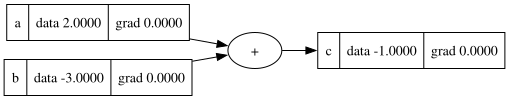

In [22]:
draw_dot(c)